# Projet — Comparaison CNN vs Vision Transformer
**Erwan Ouabdesselam**

Ce notebook est un complément au TP2 : l'objectif est de comparer des approches CNN et Vision Transformer sur une tâche de classification d'images médicales.

J'utilise PathMNIST (patches colorectaux, 9 classes, ~90 000 images) parce que c'est un benchmark standard bien équilibré, adapté pour comparer des architectures sans biais de collecte.

Trois modèles comparés, dans un ordre progressif :
- **ResNet50** — CNN classique, sert de baseline
- **DeiT-Small** — Vision Transformer pur, approche opposée
- **ConvNeXt-Tiny** — CNN modernisé qui s'inspire des ViT, synthèse des deux

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

import medmnist
from medmnist import PathMNIST

import timm
import time, copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA L4


## 1. Chargement des données

In [2]:
CLASS_NAMES = ['Adipose', 'Background', 'Debris', 'Lymphocytes',
               'Mucus', 'Smooth muscle', 'Normal colon', 'Stroma', 'Tumor']

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class CachedDataset(torch.utils.data.Dataset):
    """
    Stocke les images en uint8 (~1.1 GB pour 90k images 64x64)
    au lieu de float32 (~4.4 GB) pour ne pas saturer la RAM.
    La conversion float + normalisation se fait par sample dans __getitem__.
    """
    def __init__(self, mnistset, augment=False):
        self.imgs   = torch.from_numpy(mnistset.imgs).permute(0, 3, 1, 2).contiguous()  # uint8
        self.labels = torch.from_numpy(mnistset.labels.squeeze()).long()
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.imgs[idx].float().div_(255.0)
        img.sub_(MEAN).div_(STD)

        if self.augment:
            img = transforms.functional.resize(img, 72, antialias=True)
            i, j, h, w = transforms.RandomCrop.get_params(img, (64, 64))
            img = transforms.functional.crop(img, i, j, h, w)
            if torch.rand(1) < 0.5:
                img = transforms.functional.hflip(img)
            if torch.rand(1) < 0.5:
                img = transforms.functional.vflip(img)

        img = transforms.functional.resize(img, 224, antialias=True)
        return img, self.labels[idx]


_raw_train = PathMNIST(split='train', download=True, size=64)
_raw_val   = PathMNIST(split='val',   download=True, size=64)
_raw_test  = PathMNIST(split='test',  download=True, size=64)

train_ds = CachedDataset(_raw_train, augment=True)
val_ds   = CachedDataset(_raw_val,   augment=False)
test_ds  = CachedDataset(_raw_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}')
print(f'RAM dataset (uint8) : ~{(train_ds.imgs.nelement() + val_ds.imgs.nelement() + test_ds.imgs.nelement()) / 1e9:.2f} GB')

Train : 89996 | Val : 10004 | Test : 7180
RAM dataset (uint8) : ~1.32 GB


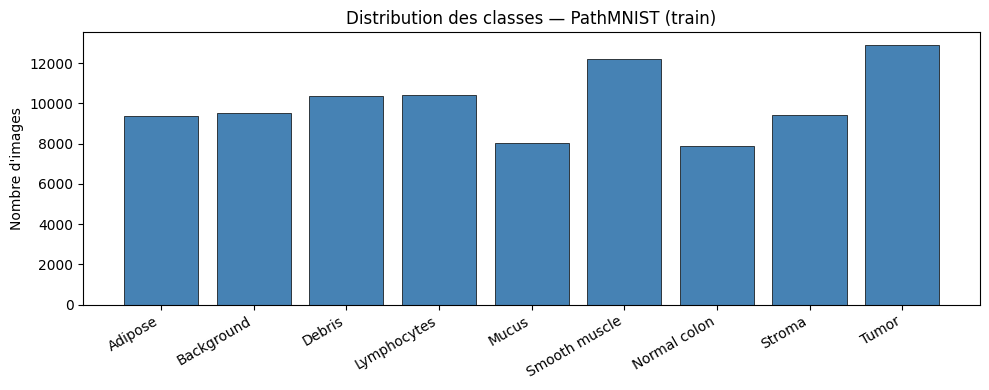

In [3]:
# Vérification de la distribution des classes
label_list = train_ds.labels.numpy().tolist()
counts = [label_list.count(i) for i in range(9)]

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Distribution des classes — PathMNIST (train)')
plt.xticks(rotation=30, ha='right')
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()


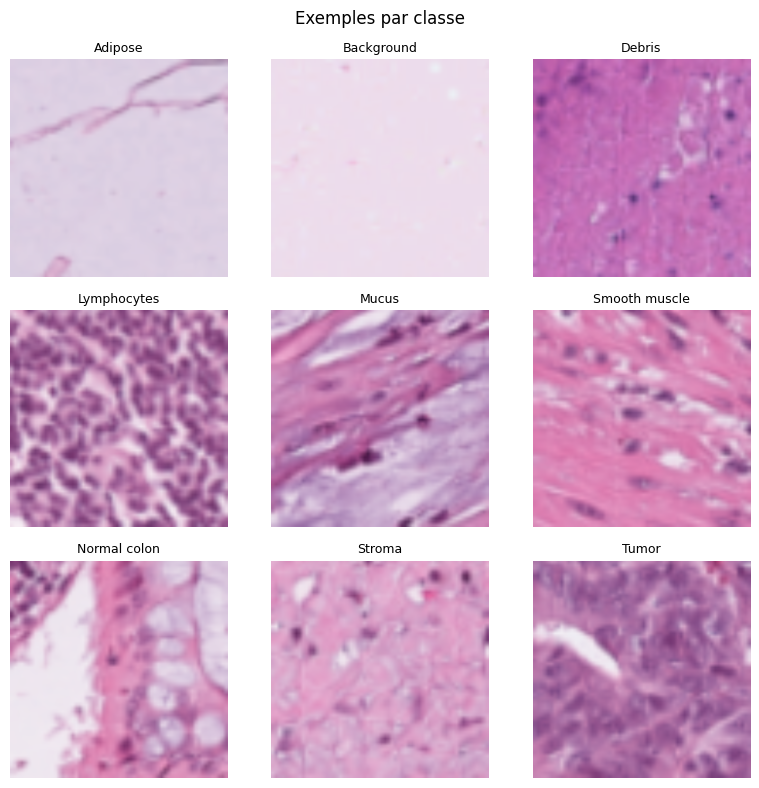

In [4]:
# Quelques exemples d'images
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

_STD  = [0.229, 0.224, 0.225]  # listes pour np.array (pas tenseurs shape (3,1,1))
_MEAN = [0.485, 0.456, 0.406]

shown = set()
# Cherche un index par classe directement dans les labels en RAM
for cls in range(9):
    idx = (train_ds.labels == cls).nonzero(as_tuple=True)[0][0].item()
    img, label = train_ds[idx]
    img_np = (img.permute(1, 2, 0).numpy() * np.array(_STD) + np.array(_MEAN)).clip(0, 1)
    axes[cls].imshow(img_np)
    axes[cls].set_title(CLASS_NAMES[cls], fontsize=9)
    axes[cls].axis('off')

plt.suptitle('Exemples par classe')
plt.tight_layout()
plt.show()


## 2. Entraînement des modèles

J'utilise une stratégie de transfer learning en deux phases pour les trois modèles :

- **Phase 1** (3 epochs) : le backbone reste gelé, seule la tête de classification est entraînée. Ça permet une convergence rapide sans risquer de déstabiliser les features pré-entraînées.
- **Phase 2** (7 epochs max) : le dernier bloc du backbone est dégelé, fine-tuning léger avec AdamW lr=1e-4, cosine annealing et early stopping (patience=3).

CrossEntropyLoss, weight decay=1e-4 pour tous. Le dataset est équilibré donc pas besoin de pondérer les classes.

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.long().to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    correct = total = 0
    total_loss = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.long().to(device, non_blocking=True)
        with torch.amp.autocast('cuda'):
            out   = model(imgs)
            preds = out.argmax(1)
            if criterion is not None:
                total_loss += criterion(out, labels).item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    val_loss = total_loss / total if criterion is not None else None
    return correct / total, all_preds, all_labels, val_loss


def two_phase_train(model, head_params, last_block_params,
                    train_loader, val_loader, criterion,
                    phase1_epochs=3, phase2_epochs=7, patience=3):
    history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_loss': []}
    best_acc, best_weights = 0, None
    scaler = torch.amp.GradScaler('cuda')

    # ── Phase 1 : tête seule ──
    print('── Phase 1 : tête seule ──')
    for p in model.parameters():
        p.requires_grad = False
    for p in head_params:
        p.requires_grad = True

    opt1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)

    for epoch in range(phase1_epochs):
        tr_loss, tr_acc       = train_one_epoch(model, train_loader, opt1, criterion, scaler)
        val_acc, _, _, val_loss = evaluate(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)
        print(f'  Ep {epoch+1:2d} | loss={tr_loss:.4f} | val_loss={val_loss:.4f} | train={tr_acc:.3f} | val={val_acc:.3f}')
        if val_acc > best_acc:
            best_acc, best_weights = val_acc, copy.deepcopy(model.state_dict())

    # ── Phase 2 : dernier bloc + tête ──
    print('── Phase 2 : dernier bloc + tête ──')
    for p in last_block_params:
        p.requires_grad = True

    opt2  = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=phase2_epochs, eta_min=1e-6)
    pat   = 0

    for epoch in range(phase2_epochs):
        tr_loss, tr_acc       = train_one_epoch(model, train_loader, opt2, criterion, scaler)
        val_acc, _, _, val_loss = evaluate(model, val_loader, criterion)
        sched.step()
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)
        print(f'  Ep {phase1_epochs+epoch+1:2d} | loss={tr_loss:.4f} | val_loss={val_loss:.4f} | train={tr_acc:.3f} | val={val_acc:.3f}')
        if val_acc > best_acc:
            best_acc, best_weights, pat = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            pat += 1
            if pat == patience:
                print('  Early stopping')
                break

    model.load_state_dict(best_weights)
    return model, history


criterion = nn.CrossEntropyLoss()


### ResNet50

Je commence par ResNet50 comme baseline. C'est un CNN classique : il apprend à reconnaître des patterns locaux dans l'image (formes, textures, contours) et ça marche peu importe où ces patterns se trouvent dans l'image. Sur PathMNIST c'est pertinent parce que ce qui distingue les classes c'est souvent la présence de certaines structures, des noyaux cellulaires, des glandes, pas leur position exacte.

Je l'utilise pré-entraîné sur ImageNet. Les features apprises sur des photos naturelles (contours, textures de base) restent utiles même sur des images médicales.

In [6]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(resnet.fc.in_features, 9))
resnet = resnet.to(device)

t0 = time.time()
resnet, history_rn = two_phase_train(
    model            = resnet,
    head_params      = list(resnet.fc.parameters()),
    last_block_params= list(resnet.layer4.parameters()),
    train_loader     = train_loader,
    val_loader       = val_loader,
    criterion        = criterion,
    phase1_epochs    = 3,
    phase2_epochs    = 7,
    patience         = 3,
)

test_acc_rn, preds_rn, labels_test, _ = evaluate(resnet, test_loader)
f1_rn       = f1_score(labels_test, preds_rn, average='macro')
n_params_rn = sum(p.numel() for p in resnet.parameters()) / 1e6
time_rn     = (time.time() - t0) / 60

print(f'\nResNet50 — Test acc={test_acc_rn:.4f} | F1={f1_rn:.4f} | {n_params_rn:.0f}M params | {time_rn:.1f}min')


── Phase 1 : tête seule ──


  Ep  1 | loss=0.4548 | val_loss=0.5338 | train=0.877 | val=0.828
  Ep  2 | loss=0.2562 | val_loss=0.4654 | train=0.920 | val=0.843
  Ep  3 | loss=0.2286 | val_loss=0.4135 | train=0.926 | val=0.858
── Phase 2 : dernier bloc + tête ──
  Ep  4 | loss=0.1127 | val_loss=0.2791 | train=0.963 | val=0.914
  Ep  5 | loss=0.0599 | val_loss=0.2851 | train=0.980 | val=0.917
  Ep  6 | loss=0.0415 | val_loss=0.2373 | train=0.986 | val=0.927
  Ep  7 | loss=0.0316 | val_loss=0.1719 | train=0.989 | val=0.947
  Ep  8 | loss=0.0266 | val_loss=0.2196 | train=0.991 | val=0.932
  Ep  9 | loss=0.0207 | val_loss=0.1888 | train=0.993 | val=0.946
  Ep 10 | loss=0.0168 | val_loss=0.1765 | train=0.994 | val=0.948

ResNet50 — Test acc=0.9000 | F1=0.8559 | 24M params | 18.7min


### DeiT-Small (Vision Transformer)

Maintenant l'approche opposée. Là où ResNet regarde des patches locaux, DeiT découpe l'image en 196 tokens (patches 16×16) et applique de l'attention entre tous les tokens en même temps. Aucun biais de localité, le réseau doit apprendre lui-même quelles zones regarder, ce qui est en théorie avantageux quand les indices de classification sont répartis dans toute l'image.

J'utilise DeiT plutôt que ViT-B/16 parce qu'il est conçu pour fonctionner sur ImageNet-1k sans données supplémentaires, et il est plus léger (22M params vs 86M). Sur ce volume de données, ViT-B aurait probablement overfitté.

In [7]:
class CachedDatasetVit(CachedDataset):
    """Mêmes données que CachedDataset mais avec une augmentation plus forte pour le ViT."""
    def __getitem__(self, idx):
        img = self.imgs[idx].float().div_(255.0)
        img.sub_(MEAN).div_(STD)
        if self.augment:
            img = transforms.functional.resize(img, 80, antialias=True)
            i, j, h, w = transforms.RandomCrop.get_params(img, (64, 64))
            img = transforms.functional.crop(img, i, j, h, w)
            if torch.rand(1) < 0.5:
                img = transforms.functional.hflip(img)
            if torch.rand(1) < 0.5:
                img = transforms.functional.vflip(img)
            if torch.rand(1) < 0.5:
                angle = float(torch.empty(1).uniform_(-20, 20))
                img = transforms.functional.rotate(img, angle)
        img = transforms.functional.resize(img, 224, antialias=True)
        return img, self.labels[idx]

train_ds_vit     = CachedDatasetVit(_raw_train, augment=True)
train_loader_vit = DataLoader(train_ds_vit, batch_size=128, shuffle=True,
                               num_workers=4, pin_memory=True)

# DeiT-Small : 196 tokens (patches 16×16) + self-attention global
deit = timm.create_model('deit_small_patch16_224', pretrained=True, num_classes=9)
deit.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(deit.head.in_features, 9))
if hasattr(deit, 'head_dist'):
    deit.head_dist = None
deit = deit.to(device)

t0 = time.time()
deit, history_deit = two_phase_train(
    model            = deit,
    head_params      = list(deit.head.parameters()),
    last_block_params= list(deit.blocks[-2:].parameters()),  # 2 derniers blocs transformer
    train_loader     = train_loader_vit,
    val_loader       = val_loader,
    criterion        = criterion,
    phase1_epochs    = 3,
    phase2_epochs    = 7,
    patience         = 3,
)

test_acc_deit, preds_deit, _, _ = evaluate(deit, test_loader)
f1_deit       = f1_score(labels_test, preds_deit, average='macro')
n_params_deit = sum(p.numel() for p in deit.parameters()) / 1e6
time_deit     = (time.time() - t0) / 60

print(f'\nDeiT-Small — Test acc={test_acc_deit:.4f} | F1={f1_deit:.4f} | {n_params_deit:.0f}M params | {time_deit:.1f}min')

── Phase 1 : tête seule ──


  Ep  1 | loss=0.5993 | val_loss=0.2843 | train=0.809 | val=0.913
  Ep  2 | loss=0.4328 | val_loss=0.2422 | train=0.855 | val=0.925
  Ep  3 | loss=0.4136 | val_loss=0.2355 | train=0.862 | val=0.927
── Phase 2 : dernier bloc + tête ──
  Ep  4 | loss=0.2671 | val_loss=0.1240 | train=0.910 | val=0.961
  Ep  5 | loss=0.1688 | val_loss=0.0925 | train=0.944 | val=0.972
  Ep  6 | loss=0.1269 | val_loss=0.0823 | train=0.958 | val=0.974
  Ep  7 | loss=0.1070 | val_loss=0.0680 | train=0.965 | val=0.979
  Ep  8 | loss=0.0913 | val_loss=0.0637 | train=0.970 | val=0.980
  Ep  9 | loss=0.0810 | val_loss=0.0598 | train=0.973 | val=0.981
  Ep 10 | loss=0.0741 | val_loss=0.0542 | train=0.976 | val=0.983

DeiT-Small — Test acc=0.9272 | F1=0.8949 | 22M params | 18.8min


In [8]:
import gc
# libère la VRAM entre les modèles
torch.cuda.empty_cache()
gc.collect()
print(f'VRAM libre : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')


VRAM libre : 22.7 GB


### ConvNeXt-Tiny

ConvNeXt c'est un peu la synthèse des deux : c'est un CNN, donc il garde le biais de localité, mais son architecture a été repensée en s'inspirant des ViT (convolutions 7×7, LayerNorm, GELU). L'idée c'est de voir si on peut avoir le meilleur des deux mondes.


In [9]:
convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
convnext.classifier[2] = nn.Sequential(
    nn.Dropout(0.3), nn.Linear(convnext.classifier[2].in_features, 9))
convnext = convnext.to(device)

t0 = time.time()
convnext, history_cnx = two_phase_train(
    model            = convnext,
    head_params      = list(convnext.classifier.parameters()),
    last_block_params= list(convnext.features[-1].parameters()),
    train_loader     = train_loader,
    val_loader       = val_loader,
    criterion        = criterion,
    phase1_epochs    = 3,
    phase2_epochs    = 7,
    patience         = 3,
)

test_acc_cnx, preds_cnx, _, _ = evaluate(convnext, test_loader)
f1_cnx       = f1_score(labels_test, preds_cnx, average='macro')
n_params_cnx = sum(p.numel() for p in convnext.parameters()) / 1e6
time_cnx     = (time.time() - t0) / 60

print(f'\nConvNeXt — Test acc={test_acc_cnx:.4f} | F1={f1_cnx:.4f} | {n_params_cnx:.0f}M params | {time_cnx:.1f}min')

── Phase 1 : tête seule ──
  Ep  1 | loss=0.4053 | val_loss=0.1978 | train=0.879 | val=0.936
  Ep  2 | loss=0.2483 | val_loss=0.1561 | train=0.918 | val=0.950
  Ep  3 | loss=0.2308 | val_loss=0.1530 | train=0.923 | val=0.950
── Phase 2 : dernier bloc + tête ──
  Ep  4 | loss=0.1736 | val_loss=0.1046 | train=0.943 | val=0.966
  Ep  5 | loss=0.1218 | val_loss=0.0795 | train=0.960 | val=0.975
  Ep  6 | loss=0.0964 | val_loss=0.0743 | train=0.968 | val=0.977
  Ep  7 | loss=0.0783 | val_loss=0.0716 | train=0.974 | val=0.977
  Ep  8 | loss=0.0658 | val_loss=0.0695 | train=0.978 | val=0.979
  Ep  9 | loss=0.0582 | val_loss=0.0794 | train=0.981 | val=0.975
  Ep 10 | loss=0.0536 | val_loss=0.0717 | train=0.982 | val=0.979

ConvNeXt — Test acc=0.9444 | F1=0.9163 | 28M params | 20.9min


## 3. Comparaison des résultats

In [10]:
models_names = ['ResNet50', 'ConvNeXt-Tiny', 'DeiT-Small']

import pandas as pd

results = pd.DataFrame([
    {'Modèle': 'ResNet50',     'Famille': 'CNN', 'Accuracy': test_acc_rn,   'Macro F1': f1_rn,   'Params (M)': n_params_rn,   'Temps (min)': time_rn},
    {'Modèle': 'ConvNeXt-Tiny','Famille': 'CNN', 'Accuracy': test_acc_cnx,  'Macro F1': f1_cnx,  'Params (M)': n_params_cnx,  'Temps (min)': time_cnx},
    {'Modèle': 'DeiT-Small',   'Famille': 'ViT', 'Accuracy': test_acc_deit, 'Macro F1': f1_deit, 'Params (M)': n_params_deit, 'Temps (min)': time_deit},
]).round(4)

print(results.to_string(index=False))

       Modèle Famille  Accuracy  Macro F1  Params (M)  Temps (min)
     ResNet50     CNN    0.9000    0.8559     23.5265      18.7154
ConvNeXt-Tiny     CNN    0.9444    0.9163     27.8270      20.9138
   DeiT-Small     ViT    0.9272    0.8949     21.6691      18.8478


Les trois modèles sont au dessus de 89%, ce qui est déjà pas mal pour 10 epochs de fine-tuning. ConvNeXt prend la tête avec 94.4% et un F1 à 0.916, suivi de près par DeiT à 92.7%. ResNet50 est clairement derrière, avec 5 points d'écart sur le meilleur modèle.

Ce qui est notable c'est que DeiT talonne ConvNeXt tout en étant plus léger (22M params vs 28M) et plus rapide à entraîner. ResNet50 est le plus pénalisé en F1 (0.86), signe qu'il se plante plus souvent sur certaines classes.

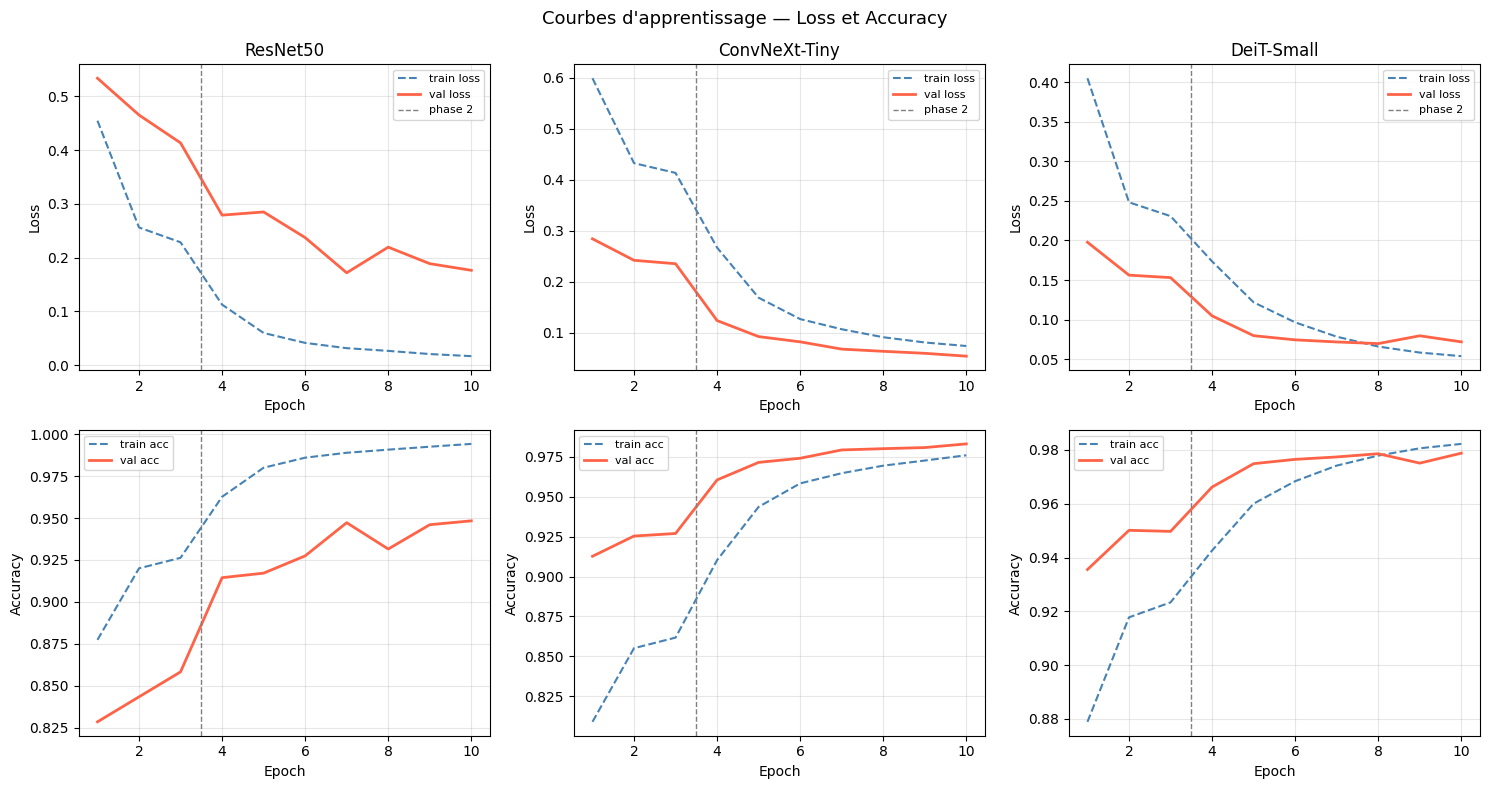

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (hist, name) in enumerate(zip([history_rn, history_deit, history_cnx], models_names)):
    eps = range(1, len(hist['train_acc']) + 1)
    phase2_start = 3

    # Ligne du haut : loss train + val
    ax_loss = axes[0, col]
    ax_loss.plot(eps, hist['train_loss'], label='train loss', color='steelblue', ls='--')
    ax_loss.plot(eps, hist['val_loss'],   label='val loss',   color='tomato',    lw=2)
    ax_loss.axvline(x=phase2_start + 0.5, color='gray', ls='--', lw=1, label='phase 2')
    ax_loss.set_title(name)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    # Ligne du bas : accuracy train + val
    ax_acc = axes[1, col]
    ax_acc.plot(eps, hist['train_acc'], label='train acc', color='steelblue', ls='--')
    ax_acc.plot(eps, hist['val_acc'],   label='val acc',   color='tomato',    lw=2)
    ax_acc.axvline(x=phase2_start + 0.5, color='gray', ls='--', lw=1)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — Loss et Accuracy", fontsize=13)
plt.tight_layout()
plt.show()


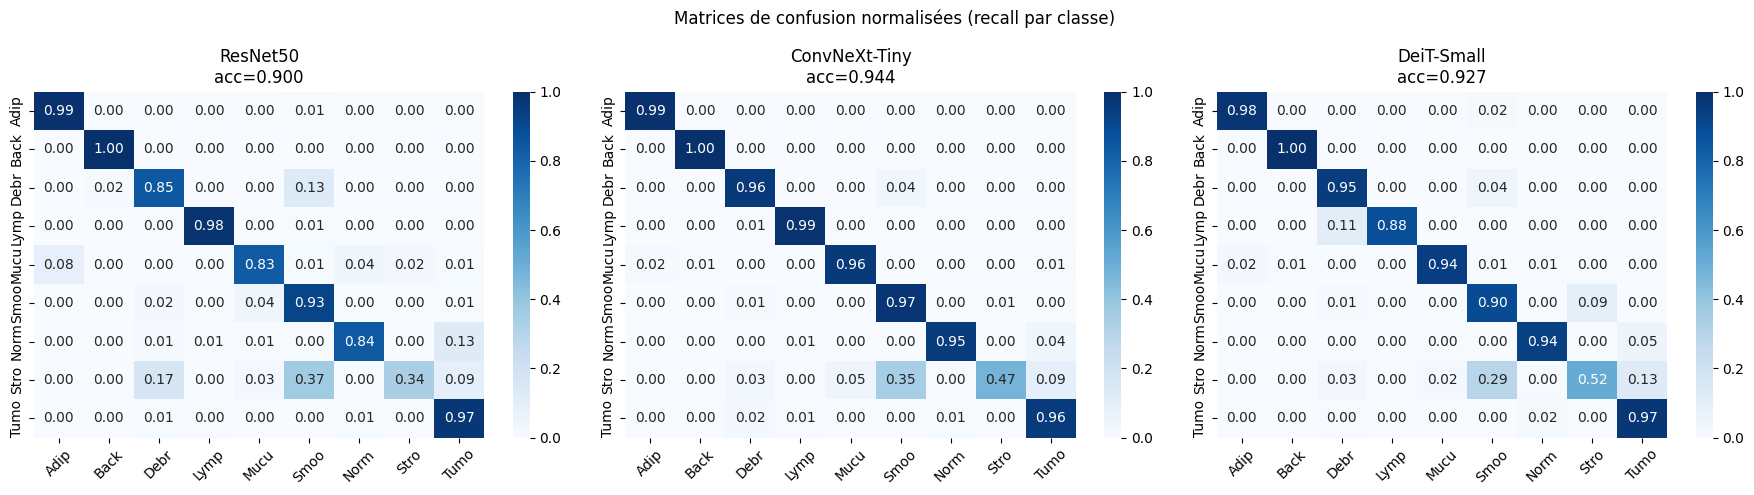

In [12]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, name in zip(axes,
                            [preds_rn, preds_cnx, preds_deit],
                            models_names):
    cm = confusion_matrix(labels_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[c[:4] for c in CLASS_NAMES],
                yticklabels=[c[:4] for c in CLASS_NAMES],
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'{name}\nacc={accuracy_score(labels_test, preds):.3f}')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Matrices de confusion normalisées (recall par classe)')
plt.tight_layout()
plt.show()

- **Background et Adipose** sont parfaitement classés par les trois modèles (recall ≥ 0.98), ces classes sont visuellement très distinctes.
- **Stroma** est le point faible commun : recall de 0.34 pour ResNet50, 0.47 pour ConvNeXt, 0.52 pour DeiT. Les trois modèles le confondent avec Smooth muscle (0.37, 0.35, 0.29). Le stroma et le muscle lisse ont des textures fibreuses proches, ce qui explique la confusion.
- **Normal colon** pose problème pour ResNet50 : 13% des cas sont classés Tumor. C'est la confusion la plus gênante cliniquement.
- **Debris** est difficile pour ResNet50 (0.85) mais ConvNeXt et DeiT s'en sortent bien (0.96 et 0.95).
- **Tumor** est bien détecté partout (0.96-0.97), ce qui est rassurant.

## 4. Interprétabilité — GradCAM

Pour comprendre ce que chaque modèle regarde vraiment, j'applique GradCAM sur les trois modèles. On calcule le gradient du score de la classe prédite par rapport aux activations de la dernière couche cible, ce qui donne une carte de chaleur des régions influentes.

Pour DeiT, il n'y a pas de couche convolutive, on cible le dernier bloc transformer et un  reconvertit les 196 tokens de patch en grille 14×14.

In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def reshape_transform_deit(tensor):
    # [batch, 197, 384] → enlève CLS token → grille 14×14
    result = tensor[:, 1:, :].reshape(tensor.size(0), 14, 14, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)


def denorm(t):
    _mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    _std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t.cpu() * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()


models_gradcam = {
    'ResNet50':      (resnet,   [resnet.layer4[-1]],           None),
    'DeiT-Small':    (deit,     [deit.blocks[-1].norm1],       reshape_transform_deit),
    'ConvNeXt-Tiny': (convnext, [convnext.features[-1][-1]],   None),
}

cams = {
    name: GradCAM(model=m, target_layers=tl, reshape_transform=rt)
    for name, (m, tl, rt) in models_gradcam.items()
}
print('GradCAM prêt pour les 3 modèles.')

GradCAM prêt pour les 3 modèles.


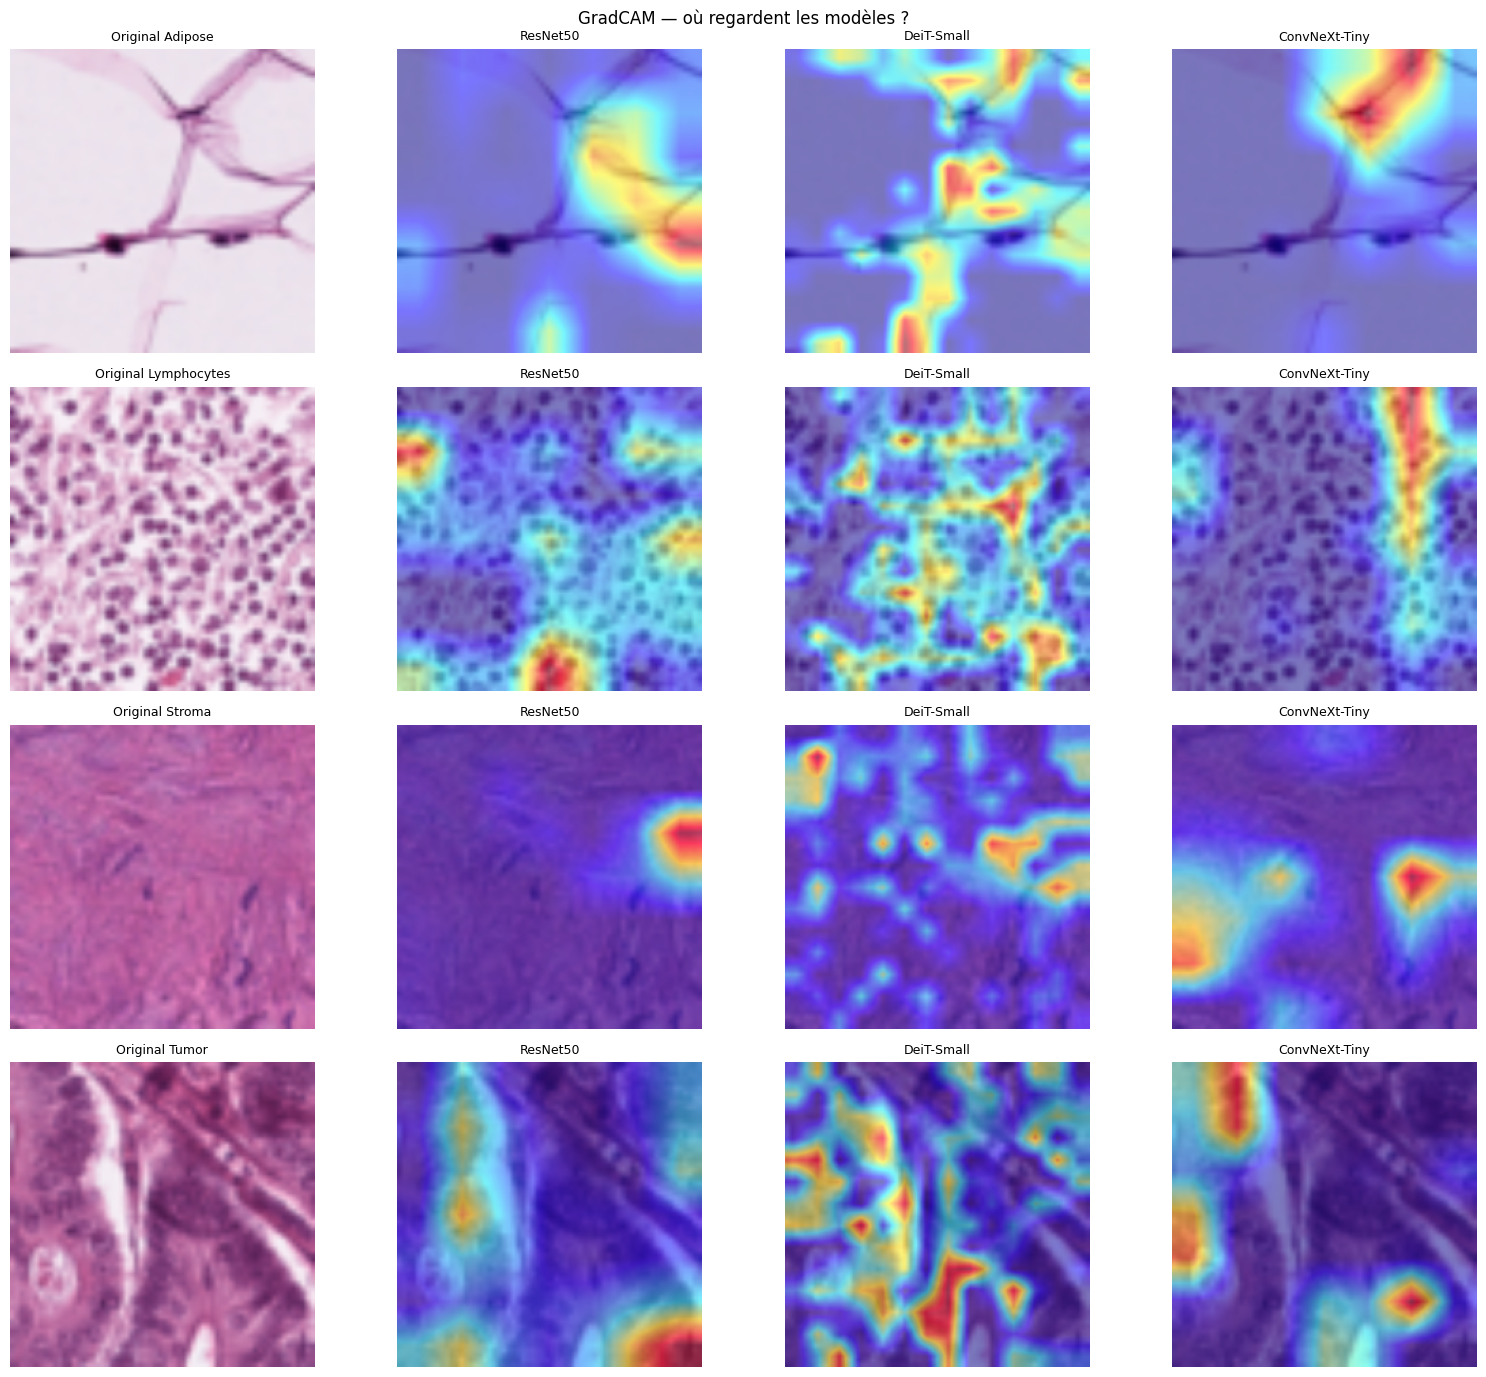

In [15]:
SHOW = [0, 3, 7, 8]  # Adipose, Lymphocytes, Stroma, Tumor
model_names_ordered = ['ResNet50', 'DeiT-Small', 'ConvNeXt-Tiny']

samples = []
for cls in SHOW:
    idx = (test_ds.labels == cls).nonzero(as_tuple=True)[0][0].item()
    img, label = test_ds[idx]
    samples.append((img.unsqueeze(0), int(label.item())))

fig, axes = plt.subplots(len(SHOW), 4, figsize=(16, len(SHOW)*3.5))

for row, (img_t, lbl) in enumerate(samples):
    img_np = denorm(img_t[0])

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f'Original {CLASS_NAMES[lbl]}', fontsize=9)
    axes[row, 0].axis('off')

    for col, name in enumerate(model_names_ordered, start=1):
        cam_obj = cams[name]
        targets = [ClassifierOutputTarget(lbl)]
        grayscale_cam = cam_obj(input_tensor=img_t.to(device), targets=targets)
        visualization = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)
        axes[row, col].imshow(visualization)
        axes[row, col].set_title(name, fontsize=9)
        axes[row, col].axis('off')

plt.suptitle('GradCAM — où regardent les modèles ?', fontsize=12)
plt.tight_layout()
plt.show()

Les cartes Grad-CAM permettent de voir concrètement sur quelles zones les modèles se basent pour faire leur prédiction.

On remarque d’abord que **ResNet50** a tendance à se concentrer sur des régions assez localisées et visuellement pertinentes. Par exemple, sur les images d’adipose ou de tumeur, il met bien en évidence les contours ou certaines structures marquées. Les zones activées sont assez propres, ce qui donne confiance dans ce que le modèle apprend.

À l’inverse, **DeiT-Small** produit des cartes beaucoup plus diffuses. L’attention est plus répartie sur l’ensemble de l’image, avec moins de focalisation sur des zones précises. On a l’impression qu’il capte davantage des motifs globaux, mais de manière moins ciblée.

**ConvNeXt-Tiny** se situe un peu entre les deux. Les activations sont plus concentrées que pour DeiT, mais parfois moins nettes que celles de ResNet50. Il semble combiner à la fois une vision locale et une prise en compte plus globale du contexte.

Si on regarde rapidement par type de tissu :
- pour **adipose**, les modèles regardent surtout les contours des cellules, ce qui est logique,
- pour **lymphocytes**, ils se focalisent sur les zones denses en noyaux,
- pour **stroma**, les activations sont plus étalées, ce qui reflète le caractère moins structuré,
- pour **tumor**, on voit une attention portée sur des structures irrégulières.

Globalement, ResNet50 donne les cartes les plus lisibles, DeiT est plus diffus, et ConvNeXt propose un compromis entre les deux.

## 5. Discussion

Les trois modèles atteignent de bonnes performances sur PathMNIST grâce au pré-entraînement ImageNet. J'ai utilisé une stratégie en deux phases : backbone gelé d'abord (3 epochs, lr=1e-3) puis fine-tuning du dernier bloc (7 epochs max, lr=1e-4). Ça converge bien sans réentraîner 25M paramètres inutilement.

**CNN vs ViT.** ConvNeXt gagne avec la meilleure accuracy et le meilleur F1, devant DeiT. Ce n'est pas vraiment surprenant : les images histologiques ont des structures locales (noyaux, glandes, fibres) et les convolutions sont faites pour ça. Le ViT fait de l'attention globale entre tous les patches, c'est puissant mais ça demande beaucoup de données. Avec ~90k images, il n'exploite pas encore tout son potentiel.

**Pourquoi ConvNeXt bat aussi ResNet50.** ConvNeXt n'est pas un CNN classique : il s'est inspiré des ViT (kernels depthwise 7×7, LayerNorm, GELU) tout en gardant la structure convolutive. En pratique il prend le meilleur des deux mondes, ce qui explique qu'il soit devant les deux autres ici.

**Stroma : le point faible commun.** Recall faible sur les trois modèles. Le stroma est visuellement ambigu, ses textures ressemblent à d'autres classes selon l'image. Les GradCAM le confirment : les activations sont éparses, les modèles n'ont pas de région clairement discriminante à regarder.

